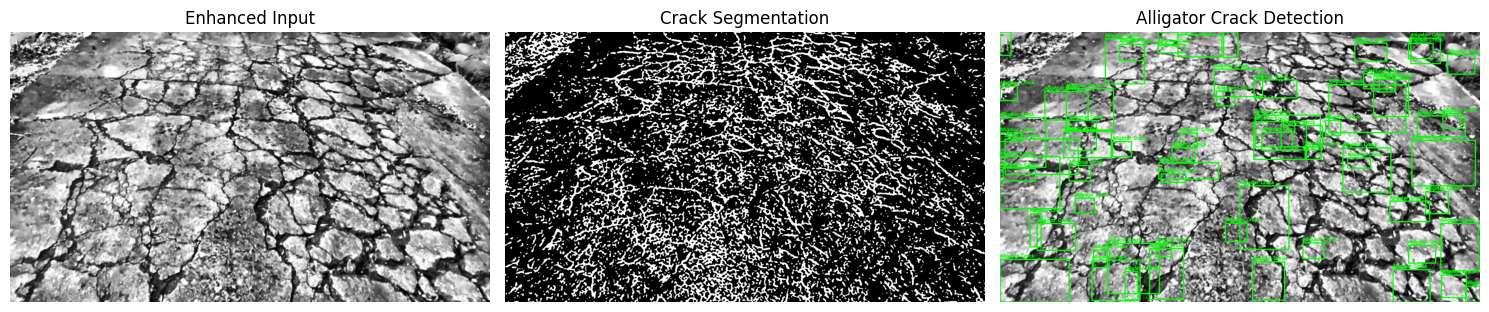

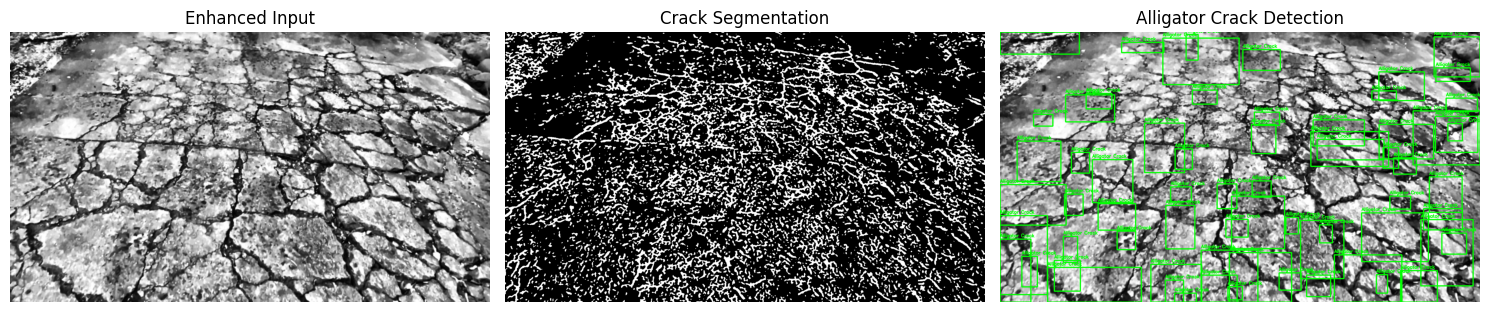

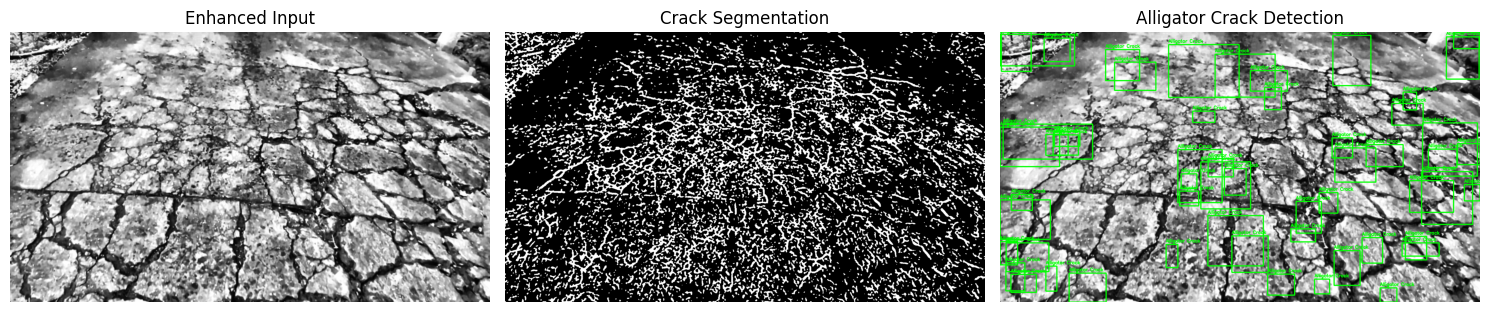

Alligator crack detection completed successfully!


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Folder structure
input_folder = "../../frames/enhanced/4_FinalEnhanced/AligatorCracking"
output_folder = "../../frames/segmented/AlligatorCracking"

os.makedirs(output_folder, exist_ok=True)

max_show = 3
count = 0


# Segment alligator cracks
def segment_alligator(gray):

    # Step 1: Light smoothing
    blur = cv2.GaussianBlur(gray, (3,3), 0)

    # Step 2: Blackhat enhancement
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (9,9)
    )

    blackhat = cv2.morphologyEx(
        blur,
        cv2.MORPH_BLACKHAT,
        kernel
    )

    # Step 3: Binary threshold
    _, binary = cv2.threshold(
        blackhat,
        20,
        255,
        cv2.THRESH_BINARY
    )

    # Step 4: Remove tiny noise
    open_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3,3)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        open_kernel,
        iterations=1
    )

    # Step 5: Moderate connection
    # Prevent whole-image merging
    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        close_kernel,
        iterations=1
    )

    return binary


# Merge nearby boxes
def merge_boxes(boxes, distance=35):

    merged_boxes = []

    while boxes:

        x1, y1, x2, y2 = boxes.pop(0)

        merged = True

        while merged:

            merged = False

            remove_indices = []

            for i, (xx1, yy1, xx2, yy2) in enumerate(boxes):

                # Check nearby distance
                if (
                    abs(xx1 - x2) < distance or
                    abs(x1 - xx2) < distance
                ) and (
                    abs(yy1 - y2) < distance or
                    abs(y1 - yy2) < distance
                ):

                    x1 = min(x1, xx1)
                    y1 = min(y1, yy1)
                    x2 = max(x2, xx2)
                    y2 = max(y2, yy2)

                    remove_indices.append(i)

                    merged = True

            for index in sorted(remove_indices, reverse=True):
                boxes.pop(index)

        merged_boxes.append([x1, y1, x2, y2])

    return merged_boxes


# Detect alligator crack regions
def detect_alligator_regions(image, mask):

    output = image.copy()

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    # Small crack cell detection
    for c in contours:

        area = cv2.contourArea(c)

        if 100 < area < 2500:

            x, y, w, h = cv2.boundingRect(c)

            aspect_ratio = w / float(h + 1e-5)

            # Ignore long lines
            if 0.4 < aspect_ratio < 3.5:

                boxes.append([x, y, x+w, y+h])

    # Merge nearby boxes moderately
    merged_boxes = merge_boxes(boxes)

    # Draw medium-sized regions only
    for box in merged_boxes:

        x1, y1, x2, y2 = box

        width = x2 - x1
        height = y2 - y1

        area = width * height

        # Prevent huge full-image box
        if 3000 < area < 60000:

            cv2.rectangle(
                output,
                (x1, y1),
                (x2, y2),
                (0,255,0),
                3
            )

            cv2.putText(
                output,
                "Alligator Crack",
                (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )

    return output


# Main processing loop
for file in os.listdir(input_folder):

    if file.endswith((".jpg", ".png", ".jpeg")):

        path = os.path.join(input_folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Segment cracks
        mask = segment_alligator(gray)

        # Detect regions
        result = detect_alligator_regions(img, mask)

        # Save
        cv2.imwrite(
            os.path.join(output_folder, file),
            result
        )

        # Visualization
        if count < max_show:

            plt.figure(figsize=(15,5))

            plt.subplot(1,3,1)
            plt.imshow(gray, cmap="gray")
            plt.title("Enhanced Input")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(mask, cmap="gray")
            plt.title("Crack Segmentation")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
            plt.title("Alligator Crack Detection")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            count += 1

print("Alligator crack detection completed successfully!")